# DINOv2 Zero-Shot Analysis — Shrouded vs Open Rotor VTOL Patents

**Purpose:** Extract structural embeddings from patent drawings using frozen DINOv2-large (no fine-tuning), reduce dimensionality with PCA, cluster with HDBSCAN, and visualize with UMAP.

**Architecture:** All logic lives in [`src/zero_shot.py`](../src/zero_shot.py). This notebook configures paths/hyperparameters and calls one function per stage.

| Stage | What it does |
|---|---|
| 0 — Paths | Resolve input/output directories via `src.config_loader` |
| 1 — Config | Set hyperparameters; import from `src.zero_shot` |
| 2 — Extract | Batched CLS-token extraction + patent-level mean pooling |
| **2.5 — Label check** | **Random gallery per class — verify labels before trusting results** |
| 3 — Normalize | L2-project embeddings onto the unit hypersphere |
| 3.5a — Scree plot | Plot cumulative variance vs n_components → pick PCA_N_COMPONENTS |
| 3.5b — PCA | Reduce to chosen n_components (rule of thumb: ≤ n_samples / 5 ≈ 16) |
| 4 — Cluster | HDBSCAN (`leaf` method) on PCA embeddings |
| 5 — Visualize | UMAP 2D scatter: cluster assignments + ground-truth labels side-by-side |

In [1]:
# ── Stage 0: Path Configuration ──────────────────────────────────────────────
import sys
from pathlib import Path

# Make pipeline/ importable from notebooks/
sys.path.insert(0, str(Path("..").resolve()))

from src.config_loader import load_config
cfg = load_config()

# Input: 84 processed images in class subfolders (shrouded/ and open_rotor/)
IMAGE_DIR = Path(cfg["paths"]["final"])

# Output: experiment folder / zero_shot_analysis/
ANALYSIS_DIR  = Path(cfg["paths"]["experiment"]) / "zero_shot_analysis"
OUTPUT_DIR    = ANALYSIS_DIR / "outputs"
EMBEDDING_DIR = OUTPUT_DIR / "embeddings"
PLOT_DIR      = OUTPUT_DIR / "plots"

for d in [ANALYSIS_DIR, OUTPUT_DIR, EMBEDDING_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Images  : {IMAGE_DIR}")
print(f"  exists: {IMAGE_DIR.exists()}")
print(f"Outputs : {OUTPUT_DIR}")

Images  : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed
  exists: True
Outputs : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/zero_shot_analysis/outputs


In [ ]:
# ── Stage 1: Hyperparameters & Imports ───────────────────────────────────────
import torch
import matplotlib.pyplot as plt
from src.zero_shot import (
    collect_image_paths, patent_id_from_path, category_from_path,
    initialize_dinov2, extract_embeddings,
    l2_normalize, pca_reduce, hdbscan_cluster,
    umap_project, plot_umap_clusters, plot_cluster_gallery,
    safe_save_np, safe_save_df, safe_save_plot,
)

SEED       = 42
MODEL_NAME = "facebook/dinov2-large"   # 1024-d CLS token
BATCH_SIZE = 16
DEVICE     = torch.device("cuda:1")

# PCA: rule of thumb n_components ≤ n_samples / 5  →  84 / 5 ≈ 16
# Run the scree plot cell (Stage 3.5a) first, then adjust this value.
PCA_N_COMPONENTS = 16

# HDBSCAN: try min_cluster_size 4–8 for 84 samples
HDBSCAN_MIN_CLUSTER_SIZE  = 5
HDBSCAN_MIN_SAMPLES       = 2      # lower = fewer noise points
HDBSCAN_CLUSTER_SELECTION = "leaf" # "leaf" → tighter clusters; "eom" → broader

print(f"Model : {MODEL_NAME}")
print(f"Device: {DEVICE}  |  Seed: {SEED}")
print(f"PCA   : {PCA_N_COMPONENTS}d  |  HDBSCAN min_cluster_size={HDBSCAN_MIN_CLUSTER_SIZE}, "
      f"min_samples={HDBSCAN_MIN_SAMPLES}, method={HDBSCAN_CLUSTER_SELECTION}")

In [3]:
# ── Stage 2: Embedding Extraction ────────────────────────────────────────────
image_paths = collect_image_paths(IMAGE_DIR)
print(f"Found {len(image_paths)} images in {IMAGE_DIR}")

processor, model = initialize_dinov2(MODEL_NAME, DEVICE)

image_emb, img_meta_df, patent_ids, patent_emb = extract_embeddings(
    image_paths, processor, model, DEVICE, BATCH_SIZE
)

safe_save_np(patent_emb,  EMBEDDING_DIR / "patent_embeddings.npy")
safe_save_np(image_emb,   EMBEDDING_DIR / "image_embeddings.npy")
safe_save_df(img_meta_df, EMBEDDING_DIR / "image_metadata.csv")

Found 84 images in /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 6/6 [00:01<00:00,  3.85it/s]

Image embeddings:  (84, 1024)
Patent embeddings: (84, 1024)  (84 unique patents)


PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/zero_shot_analysis/outputs/embeddings/image_metadata.csv')

In [ ]:
# ── Stage 2.5: Label Quality Check ───────────────────────────────────────────
# Visually inspect random images per class BEFORE trusting any clustering result.
# Key thing to check: patents labelled "shrouded" that show open propellers for
# forward flight — those are noisy labels and will hurt both clustering and training.
import random
from PIL import Image as _PIL_Image

N_SHOW = 8   # images to sample per class; change to see more or fewer

by_class = {}
for p in image_paths:
    cls = category_from_path(p)
    by_class.setdefault(cls, []).append(p)

rng = random.Random(SEED)
for cls, paths in sorted(by_class.items()):
    sample = rng.sample(paths, min(N_SHOW, len(paths)))
    ncols  = 4
    nrows  = -(-len(sample) // ncols)   # ceiling division

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, p in zip(axes, sample):
        ax.imshow(_PIL_Image.open(p).convert("RGB"))
        ax.set_title(patent_id_from_path(p), fontsize=7, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")

    fig.suptitle(
        f"{cls.upper().replace('_', ' ')}  ·  {len(paths)} images total  "
        f"(showing {len(sample)} random)",
        fontsize=13, fontweight="bold",
        color="#1565C0" if cls == "shrouded" else "#BF360C",
    )
    fig.tight_layout()
    safe_save_plot(fig, PLOT_DIR / f"label_check_{cls}.png", dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("\nCounts per class:")
for cls, paths in sorted(by_class.items()):
    print(f"  {cls}: {len(paths)}")

In [4]:
# ── Stage 3: L2 Normalization ─────────────────────────────────────────────────
# Projects each 1024-d embedding vector onto the unit hypersphere (length = 1).
# After this, Euclidean distance is equivalent to cosine distance —
# so clustering groups patents by the *direction* (structure) of their embeddings,
# not by their magnitude.
X_norm = l2_normalize(patent_emb)

L2-normalized 84 vectors — mean norm: 1.000000, std: 7.36e-08


In [ ]:
# ── Stage 3.5a: Scree Plot — choose PCA n_components ─────────────────────────
# With 84 samples, PCA can produce at most 84 components (not 1024).
# This plot shows how many components are actually needed to capture the variance.
# Look for the "elbow" — the point where the curve flattens.
# Then set PCA_N_COMPONENTS in Stage 1 to that value and re-run from Stage 3.5b.
import numpy as np
from sklearn.decomposition import PCA as _PCA

pca_full = _PCA().fit(X_norm)
cumvar   = pca_full.explained_variance_ratio_.cumsum()

fig_scree, ax_scree = plt.subplots(figsize=(9, 4))
ax_scree.plot(range(1, len(cumvar) + 1), cumvar, marker=".", markersize=4)
ax_scree.axhline(0.90, color="orange", linestyle="--", label="90% variance")
ax_scree.axhline(0.95, color="red",    linestyle="--", label="95% variance")
ax_scree.axvline(PCA_N_COMPONENTS, color="green", linestyle=":", label=f"current: {PCA_N_COMPONENTS}d")
ax_scree.set_xlabel("Number of PCA components")
ax_scree.set_ylabel("Cumulative explained variance")
ax_scree.set_title("Scree plot — choose PCA_N_COMPONENTS at the elbow or the 90–95% line")
ax_scree.legend()
ax_scree.grid(alpha=0.3)
plt.tight_layout()
safe_save_plot(fig_scree, PLOT_DIR / "pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# Print exact component counts for 90% and 95%
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")
print(f"Current PCA_N_COMPONENTS   : {PCA_N_COMPONENTS}")

In [5]:
# ── Stage 3.5: PCA Dimensionality Reduction ───────────────────────────────────
# DINOv2-large produces 1024-d vectors. In very high dimensions, all pairwise
# distances converge to the same value (curse of dimensionality), making
# distance-based clustering unreliable. PCA keeps the most discriminative
# directions and reduces the space to 100 dimensions (advisor recommendation).
X_pca = pca_reduce(X_norm, n_components=PCA_N_COMPONENTS, seed=SEED)
safe_save_np(X_pca, EMBEDDING_DIR / "patent_embeddings_pca.npy")

PCA: 1024d → 84d  |  variance explained: 100.0%


PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/zero_shot_analysis/outputs/embeddings/patent_embeddings_pca.npy')

In [ ]:
# ── Stage 4: HDBSCAN Clustering ──────────────────────────────────────────────
cluster_df, patent_cluster_labels = hdbscan_cluster(
    X_pca,
    patent_ids,
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
)
saved = safe_save_df(cluster_df, OUTPUT_DIR / "patent_cluster_assignments_hdbscan.csv")
print(f"Assignments saved: {saved.name}")
print(cluster_df.to_string(index=False))

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP 2D projection (may take ~30 s on CPU)...
✓ UMAP complete: (84, 2)


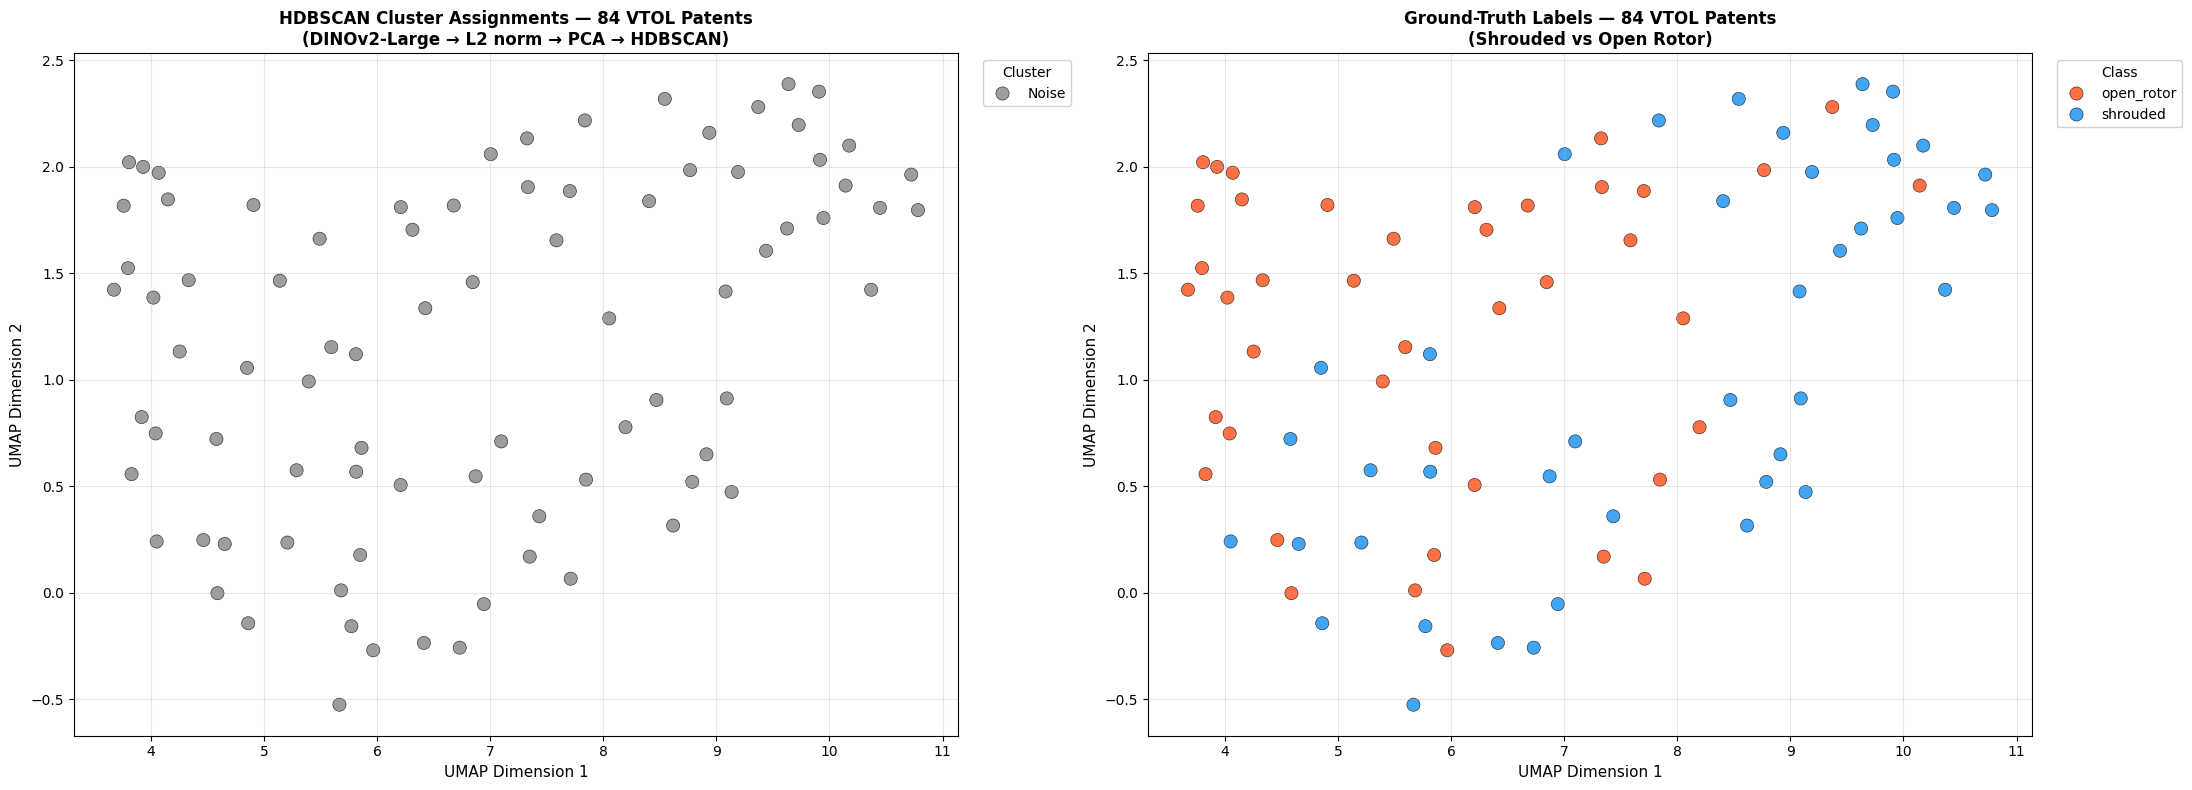

In [7]:
# ── Stage 5: UMAP Visualization ──────────────────────────────────────────────
# UMAP reduces PCA-100d embeddings to 2D for plotting.
# Left panel:  HDBSCAN cluster assignments (do the clusters make sense?)
# Right panel: Ground-truth class labels  (do shrouded/open_rotor separate?)
points_2d = umap_project(X_pca, seed=SEED)

# Build per-patent ground-truth label from filename (_SHR_ or _OPN_)
pid_to_gt = {}
for p in image_paths:
    pid = patent_id_from_path(p)
    if pid not in pid_to_gt:
        pid_to_gt[pid] = category_from_path(p)
gt_labels = [pid_to_gt.get(pid, "unknown") for pid in patent_ids]

fig = plot_umap_clusters(
    points_2d,
    patent_cluster_labels,
    patent_ids,
    title_suffix="84 VTOL Patents",
    ground_truth_labels=gt_labels,
)
safe_save_plot(fig, PLOT_DIR / "patent_clusters_umap.png", dpi=220, bbox_inches="tight")
plt.show()

plot_cluster_gallery(cluster_df, patent_ids, image_paths, PLOT_DIR)